## Content: analysis of ZTL-P and places where transit is not allowed
Check if there exist points in the routes of e-scooters that pass by ZTL-P (defined in `data/static/ZTL-P.shp`) or inside the areas where e-scooters are not allowed (the names of some of these areas are contained in `data/static/piazze escluse.txt`, and are _Piazza Duomo_ and _Piazza Fiera_ - the geometries can be obtained via OpenStreetMap - while the others not allowed areas can be found in the shapefile `data/static/parchi_con_circolazione_interdetta.shp`)

The check will be performed twice: firstly using the original data before map matching, and then using the map-matched data obtained from the notebook `MapMatching_ValhallaDocker.ipynb`.


In [110]:
import pandas as pd
import geopandas as gpd
import numpy as np
import alphashape
from shapely.geometry import Point, Polygon, LineString
import warnings
warnings.filterwarnings("ignore")

### ZTL-P

In [3]:
area = gpd.read_file("../data/static/ZTL-P.shp") 

<AxesSubplot:>

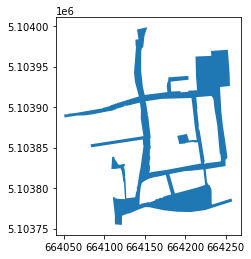

In [4]:
area.plot()

In [5]:
points = []
for idx, row in area.iterrows():
  points= points + (list(area.geometry[idx].exterior.coords))
points = np.array(points)

In [6]:
alpha_shape = alphashape.alphashape(points, 0.01)

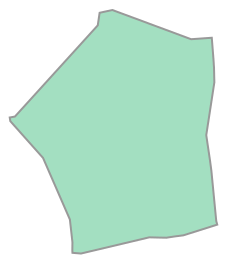

In [7]:
alpha_shape

In [8]:
# change CRS

import pyproj
from shapely.ops import transform

project = pyproj.Transformer.from_proj(
    pyproj.Proj(init='epsg:25832'), # source
    pyproj.Proj(init='epsg:4326')) # destination

# apply projection 
g2 = transform(project.transform, alpha_shape)  

c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [9]:
import folium
map = folium.Map((46.066667,11.133333), zoom_start=15)
folium.GeoJson(g2).add_to(map)
map

In [48]:
# check if e-scooters pass within the ZTL-P area
data = pd.read_parquet('../data/trips_pointv3_cleaned.parquet')
data["is_within"] = data.apply(lambda row: g2.intersects(Point(row["point_longitude"], row["point_latitude"])), axis = 1)

In [11]:
print('Points inside the ZTL-P:')
print('False:', len(data[data.is_within==False]), '\nTrue:', len(data[data.is_within==True]))

Points inside the ZTL-P:
False: 977636 
True: 19597


In [12]:
# get trips passing inside ZTL-P
dataTrue = data[data.is_within == True]
idsTrue = dataTrue.unique_id.to_list()
dataTrue = data[data['unique_id'].isin(idsTrue)]

In [13]:
dataTrue = dataTrue.reset_index()
dataTrue = dataTrue.groupby('unique_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),"point_longitude": lambda x: x.to_list()})
dataTrue["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(dataTrue["point_latitude"], dataTrue["point_longitude"])]


In [14]:
print('Number of routes that pass inside ZTL-P:', len(dataTrue))

Number of routes that pass inside ZTL-P: 1898


In [15]:
dT = dataTrue.where(dataTrue.coords.str.len()>=2)
dT = dT.dropna()
dataTrue.sort_values(by='coords', key=lambda x: x.str.len())
dT

,unique_id,point_latitude,point_longitude,coords
0,00000008-0000-1000-8ba8-5b7d6a617b60_2022-02-17,"[46.068406, 46.063910]","[11.123855, 11.123319]","[[46.068406, 11.123855], [46.063910, 11.123319]]"
1,00000017-0000-1000-8437-5b7d6a617b60_2021-02-18,"[46.068417, 46.063694]","[11.123865, 11.119309]","[[46.068417, 11.123865], [46.063694, 11.119309]]"
2,00000026-0000-1000-a3d6-5b7d6a617b60_2021-06-02,"[46.068340, 46.068420]","[11.123930, 11.123861]","[[46.068340, 11.123930], [46.068420, 11.123861]]"
3,0000003e-0000-1000-9fbe-5b7d6a617b60_2022-02-22,"[46.069279, 46.068466]","[11.113839, 11.123858]","[[46.069279, 11.113839], [46.068466, 11.123858]]"
4,00000047-0000-1000-a317-5b7d6a617b60_2021-07-06,"[46.068422, 46.073545]","[11.123827, 11.115547]","[[46.068422, 11.123827], [46.073545, 11.115547]]"
...,...,...,...,...
1893,ff3231564722_2021-05-21,"[46.068265, 46.068550, 46.068660, 46.068312, 4...","[11.122618, 11.122693, 11.123403, 11.122564, 1...","[[46.068265, 11.122618], [46.068550, 11.122693..."
1894,ffa139e080a8_2021-05-15,"[46.068015, 46.068043, 46.060790, 46.068044, 4...","[11.122898, 11.122877, 11.121883, 11.122873, 1...","[[46.068015, 11.122898], [46.068043, 11.122877..."
1895,ffe1ee671ad8_2021-09-20,"[46.068121, 46.068043, 46.067963, 46.067844, 4...","[11.122530, 11.122394, 11.122313, 11.122170, 1...","[[46.068121, 11.122530], [46.068043, 11.122394..."
1896,ffe93faddbe1_2021-09-30,"[46.064564, 46.064459, 46.064595, 46.064265, 4...","[11.120296, 11.120395, 11.120492, 11.120776, 1...","[[46.064564, 11.120296], [46.064459, 11.120395..."


In [16]:
dT = dT[1790:]
ids = dT.unique_id.to_list() # plotted trips ids

In [17]:
dT = dT.reset_index()
dT

,index,unique_id,point_latitude,point_longitude,coords
0,1798,e675e1cdf829_2021-05-10,"[46.069507, 46.069507, 46.069660, 46.069660, 4...","[11.119288, 11.119288, 11.120450, 11.120450, 1...","[[46.069507, 11.119288], [46.069507, 11.119288..."
1,1799,e6b837e11901_2021-08-10,"[46.068991, 46.068800, 46.069157, 46.069151, 4...","[11.125855, 11.126057, 11.124529, 11.123610, 1...","[[46.068991, 11.125855], [46.068800, 11.126057..."
2,1800,e702ccce-1056-46e4-9768-597b9cf13f23_2022-03-03,"[46.066580, 46.066580, 46.066268, 46.066352, 4...","[11.117250, 11.117250, 11.116895, 11.117540, 1...","[[46.066580, 11.117250], [46.066580, 11.117250..."
3,1801,e70a31a1d1f6_2021-02-25,"[46.061566, 46.061668, 46.062430, 46.064015, 4...","[11.124378, 11.124246, 11.124064, 11.123404, 1...","[[46.061566, 11.124378], [46.061668, 11.124246..."
4,1802,e7978b0a-fd1e-4666-9ac3-370b664a9ff9_2022-01-28,"[46.068744, 46.068744, 46.068708, 46.068628, 4...","[11.118990, 11.118990, 11.119014, 11.119255, 1...","[[46.068744, 11.118990], [46.068744, 11.118990..."
...,...,...,...,...,...
95,1893,ff3231564722_2021-05-21,"[46.068265, 46.068550, 46.068660, 46.068312, 4...","[11.122618, 11.122693, 11.123403, 11.122564, 1...","[[46.068265, 11.122618], [46.068550, 11.122693..."
96,1894,ffa139e080a8_2021-05-15,"[46.068015, 46.068043, 46.060790, 46.068044, 4...","[11.122898, 11.122877, 11.121883, 11.122873, 1...","[[46.068015, 11.122898], [46.068043, 11.122877..."
97,1895,ffe1ee671ad8_2021-09-20,"[46.068121, 46.068043, 46.067963, 46.067844, 4...","[11.122530, 11.122394, 11.122313, 11.122170, 1...","[[46.068121, 11.122530], [46.068043, 11.122394..."
98,1896,ffe93faddbe1_2021-09-30,"[46.064564, 46.064459, 46.064595, 46.064265, 4...","[11.120296, 11.120395, 11.120492, 11.120776, 1...","[[46.064564, 11.120296], [46.064459, 11.120395..."


In [18]:
import folium
from branca.element import Figure
import random

fig = Figure(height=550,width=750)
m = folium.Map(location=[46.067325,11.1214561], tiles='cartodbpositron', zoom_start=16)
fig.add_child(m)

n=1
  
for i in range(len(dT)):
  points = []
  points.append(dT.coords[i])
  feat = folium.FeatureGroup("Vehicle"+ str(n), show=True)
  
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]
  n+=1

  folium.vector_layers.PolyLine(points, popup=popup, tooltip=popup, color=color).add_to(feat)
  feat.add_to(m)

folium.GeoJson(g2).add_to(m)
m.add_child(folium.LayerControl())

m



In [19]:
g2.bounds

(11.121286154691504, 46.06766076566633, 11.123943437256397, 46.06984767529578)

In [41]:
# check if e-scooters pass within the ZTL-P area using map-matched data
data = pd.read_parquet('../data/map_matched_routes.parquet')

is_within=[]
for r in range(len(data)):
    l = [list([s[1],s[0]]) for s in data.at[r, 'route']] # long-lat
    if len(l)>=2:
        is_within.append(LineString(l).intersects(Polygon(g2)))
    else:
        is_within.append(Point(l[0]).intersects(g2))

data['is_within'] = is_within
print('Points inside the ZTL-P:')
print('False:', len(data[data.is_within==False]), '\nTrue:', len(data[data.is_within==True]))

Points inside the ZTL-P:
False: 78601 
True: 9322


In [34]:
dT_mm = data[data['unique_id'].isin(ids)] # ids selected for viz purposes (same ids as before)

In [35]:
dT_mm = dT_mm.reset_index()

In [36]:
dT_mm

,index,unique_id,route,matched,is_within
0,6569,eefd52018bf5_2021-02-22,"[[46.061167, 11.124767], [46.061771, 11.124149...",True,False
1,6783,e87378d80a99_2021-02-24,"[[46.061072, 11.124733], [46.061161, 11.124641...",True,False
2,7011,e70a31a1d1f6_2021-02-25,"[[46.061557, 11.124368], [46.061771, 11.124149...",True,False
3,7514,fb41abe6fcc7_2021-02-27,"[[46.069054, 11.127148], [46.069044, 11.127112...",True,True
4,7515,f37d231f23bd_2021-02-27,"[[46.069887, 11.123572], [46.069893, 11.123824]]",True,False
...,...,...,...,...,...
95,86183,ee82c90d-06b0-4b9e-b4e5-b431ee377b9f_2022-02-24,"[[46.065298, 11.131715], [46.065317, 11.131728...",True,True
96,86819,ff2316bb-5612-48c3-8374-e03fd442880b_2022-02-27,"[[46.067346, 11.127089], [46.067347, 11.127076...",True,True
97,87383,f106182e-9c5e-40da-b342-fcda12d197ec_2022-03-02,"[[46.069856, 11.122861], [46.069835, 11.122606...",True,True
98,87626,ff309a1a-943d-4981-8ac2-d7829837036c_2022-03-03,"[[46.068206, 11.117422], [46.068143, 11.117458]]",True,False


In [37]:
import folium
from branca.element import Figure
import random

fig = Figure(height=550,width=750)
m = folium.Map(location=[46.067325,11.1214561], tiles='cartodbpositron', zoom_start=16)
fig.add_child(m)

folium.GeoJson(g2).add_to(m)

n=1
  
for i in range(len(dT_mm)):
  points = []
  points.append(dT_mm.route[i])
  feat = folium.FeatureGroup("Vehicle"+ str(n), show=True)
  
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]
  n+=1

  folium.vector_layers.PolyLine(points, popup=popup, tooltip=popup, color=color).add_to(feat)
  feat.add_to(m)


m.add_child(folium.LayerControl())

m



### Piazze (Piazza Duomo e Piazza Fiera)

In [117]:
# get polygon of Piazza Duomo using Nominatim API
from geopy.geocoders import Nominatim
app = Nominatim(user_agent="piazze")

In [118]:
location = app.geocode("Piazza Duomo, Trento").raw

from pprint import pprint
pprint(location)

{'boundingbox': ['46.0669931', '46.0677421', '11.1209201', '11.1220355'],
 'class': 'place',
 'display_name': 'Piazza del Duomo, Bolghera, Centro storico Trento, Trento, '
                 "Territorio Val d'Adige, Provincia di Trento, Trentino-Alto "
                 'Adige/Südtirol, Italia',
 'importance': 0.43500000000000005,
 'lat': '46.06735185',
 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. '
            'https://osm.org/copyright',
 'lon': '11.12142670401024',
 'osm_id': 23762321,
 'osm_type': 'way',
 'place_id': 105536148,
 'type': 'square'}


In [119]:
bbox = [float(n) for n in location['boundingbox']]

In [120]:
bbox = (bbox[-2], bbox[0], bbox[-1], bbox[1])

In [121]:
import shapely.geometry
polygon_duomo = shapely.geometry.box(*bbox, ccw=True)

In [122]:
import folium
map = folium.Map((46.066667,11.133333), zoom_start=15)
folium.GeoJson(polygon_duomo).add_to(map)
map

In [123]:
# check if e-scooters pass through Piazza Duomo (before map matching)
data = pd.read_parquet('../data/trips_pointv3_cleaned.parquet')
data["is_within_duomo"] = data.apply(lambda row: polygon_duomo.intersects(Point(row["point_longitude"], row["point_latitude"])), axis = 1)

In [124]:
print('Points Piazza Duomo:')
print('False:', len(data[data.is_within_duomo==False]), '\nTrue:', len(data[data.is_within_duomo==True]))

Points Piazza Duomo:
False: 988953 
True: 8280


In [125]:
# check if e-scooters pass within piazza duomo using map-matched data
data = pd.read_parquet('../data/map_matched_routes.parquet')

is_within=[]
for r in range(len(data)):
    l = [list([s[1],s[0]]) for s in data.at[r, 'route']] # long-lat
    if len(l)>=2:
        is_within.append(LineString(l).intersects(Polygon(polygon_duomo)))
    else:
        is_within.append(Point(l[0]).intersects(polygon_duomo))

data['is_within_duomo'] = is_within
print('Points passing through Piazza Duomo:')
print('False:', len(data[data.is_within_duomo==False]), '\nTrue:', len(data[data.is_within_duomo==True]))

Points passing through Piazza Duomo:
False: 82167 
True: 5756


In [126]:
# repeat the same for Piazza Fiera
location = app.geocode("Piazza Fiera, Trento").raw
bbox = [float(n) for n in location['boundingbox']]
bbox = (bbox[-2], bbox[0], bbox[-1], bbox[1])
polygon_fiera = shapely.geometry.box(*bbox, ccw=True)

In [127]:
map = folium.Map((46.066667,11.133333), zoom_start=15)
folium.GeoJson(polygon_fiera).add_to(map)
map

In [129]:
# check if e-scooters pass through Piazza Fiera (before map matching)
data = pd.read_parquet('../data/trips_pointv3_cleaned.parquet')
data["is_within_fiera"] = data.apply(lambda row: polygon_fiera.intersects(Point(row["point_longitude"], row["point_latitude"])), axis = 1)

print('Points Piazza Fiera:')
print('False:', len(data[data.is_within_fiera==False]), '\nTrue:', len(data[data.is_within_fiera==True]))


Points Piazza Fiera:
False: 992560 
True: 4673


In [130]:
# check if e-scooters pass within piazza fiera using map-matched data
data = pd.read_parquet('../data/map_matched_routes.parquet')

is_within=[]
for r in range(len(data)):
    l = [list([s[1],s[0]]) for s in data.at[r, 'route']] # long-lat
    if len(l)>=2:
        is_within.append(LineString(l).intersects(Polygon(polygon_fiera)))
    else:
        is_within.append(Point(l[0]).intersects(polygon_fiera))

data['is_within_fiera'] = is_within
print('Points passing through Piazza Fiera:')
print('False:', len(data[data.is_within_fiera==False]), '\nTrue:', len(data[data.is_within_fiera==True]))

Points passing through Piazza Fiera:
False: 85429 
True: 2494


### Parchi con circolazione interdetta

In [64]:
area = gpd.read_file("../data/static/parchi_con_circolazione_interdetta.shp") 

<AxesSubplot:>

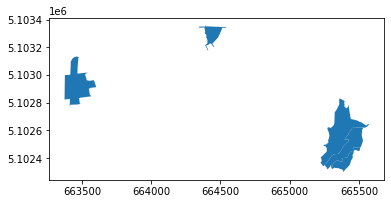

In [65]:
area.plot()

In [66]:
points = []
for idx, row in area.iterrows():
  points= points + (list(area.geometry[idx].exterior.coords))
points = np.array(points)

In [94]:
alpha_shape = alphashape.alphashape(points, 0.01)

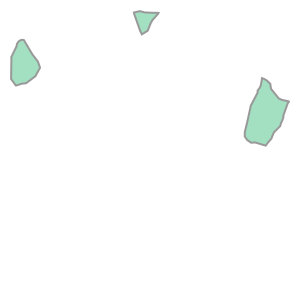

In [95]:
alpha_shape

In [69]:
# change CRS

import pyproj
from shapely.ops import transform

project = pyproj.Transformer.from_proj(
    pyproj.Proj(init='epsg:25832'), # source
    pyproj.Proj(init='epsg:4326')) # destination

# apply projection 
parchi = transform(project.transform, alpha_shape)  

c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [70]:
import folium
map = folium.Map((46.066667,11.133333), zoom_start=12)
folium.GeoJson(parchi).add_to(map)
map

In [96]:
# before map-matching
data = pd.read_parquet('../data/trips_pointv3_cleaned.parquet')
data["is_within_park"] = data.apply(lambda row: parchi.intersects(Point(row["point_longitude"], row["point_latitude"])), axis = 1)

print('Points in Parchi a Circolazione Interdetta (Albere, Giardino Solzenicy, Gocciadoro):')
print('False:', len(data[data.is_within_park==False]), '\nTrue:', len(data[data.is_within_park==True]))

Points in Parchi a Circolazione Interdetta (Albere, Giardino Solzenicy, Gocciadoro):
False: 988417 
True: 8816


C:\Users\luisa\AppData\Local\Temp\ipykernel_21320\3427227936.py:1: ShapelyDeprecationWarning: __getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  parchi[0]


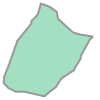

In [108]:
parchi[0]

In [ ]:
# check if e-scooters pass within the area using map-matched data
data = pd.read_parquet('../data/map_matched_routes.parquet')

is_within_gocciadoro=[]
is_within_sol=[]
is_within_albere=[]
for r in range(len(data)):
    l = [list([s[1],s[0]]) for s in data.at[r, 'route']] # long-lat
    if len(l)>=2:
        is_within_gocciadoro.append(LineString(l).intersects(Polygon(parchi[0])))
        is_within_albere.append(LineString(l).intersects(Polygon(parchi[1])))
        is_within_sol.append(LineString(l).intersects(Polygon(parchi[2])))
    else:
        is_within_gocciadoro.append(Point(l[0]).intersects(parchi[0]))
        is_within_albere.append(Point(l[0]).intersects(parchi[1]))
        is_within_sol.append(Point(l[0]).intersects(parchi[2]))

data['is_within_gocciadoro'] = is_within_gocciadoro
data['is_within_albere'] = is_within_albere
data['is_within_sol'] = is_within_sol

In [112]:
print('Points inside parks:')
print('\nParco Gocciadoro: \nFalse:', len(data[data.is_within_gocciadoro==False]), '\nTrue:', len(data[data.is_within_gocciadoro==True]))
print('\nGiardino Solzenicy: \nFalse:', len(data[data.is_within_sol==False]), '\nTrue:', len(data[data.is_within_sol==True]))
print('\nLe Albere: \nFalse:', len(data[data.is_within_albere==False]), '\nTrue:', len(data[data.is_within_albere==True]))

Points inside parks:

Parco Gocciadoro: 
False: 87896 
True: 27

Giardino Solzenicy: 
False: 85441 
True: 2482

Le Albere: 
False: 86079 
True: 1844
